In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [55]:
ml_df=pd.read_csv('ml_df.csv')

In [56]:
ml_df.set_index('ds',inplace=True)

In [57]:
ml_df.head()

,y,hour,dayofweek,month,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24
ds,,,,,,,,,
2010-12-08 08:00:00,539.450,8,2,12,0,0.000,0.00,1383.810,1296.585917
2010-12-08 09:00:00,2628.540,9,2,12,0,539.450,4865.96,4991.066,1319.063000
2010-12-08 10:00:00,4991.066,10,2,12,0,2628.540,3880.05,4991.066,1225.837167
2010-12-08 11:00:00,1997.950,11,2,12,0,4991.066,4595.98,4234.160,1272.129500
2010-12-08 12:00:00,4991.066,12,2,12,0,1997.950,2434.69,4991.066,1163.878250


In [48]:
future_steps = 120
last_date = pd.to_datetime(ml_df.index[-1])
future_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=future_steps, freq='h')

In [49]:
history = ml_df['y'].copy()

In [50]:
future_predictions = []

In [51]:
model_xgb=pickle.load(open('xgb_sales_forecast_model.pkl', 'rb'))

In [52]:
for date in future_dates:
    
    hour = date.hour
    dayofweek = date.dayofweek
    month = date.month
    is_weekend = 1 if dayofweek >= 5 else 0

    lag_1 = history.iloc[-1]
    lag_24 = history.iloc[-24]
    lag_168 = history.iloc[-168]
    rolling_mean_24 = history.iloc[-24:].mean()

    X_future = pd.DataFrame({
        'hour': [hour],
        'dayofweek': [dayofweek],
        'month': [month],
        'is_weekend': [is_weekend],
        'lag_1': [lag_1],
        'lag_24': [lag_24],
        'lag_168': [lag_168],
        'rolling_mean_24': [rolling_mean_24]
    })

    pred = model_xgb.predict(X_future)[0]
    pred = max(0, pred) 
    
    future_predictions.append(pred)
    history = pd.concat([history, pd.Series([pred], index=[date])])

    

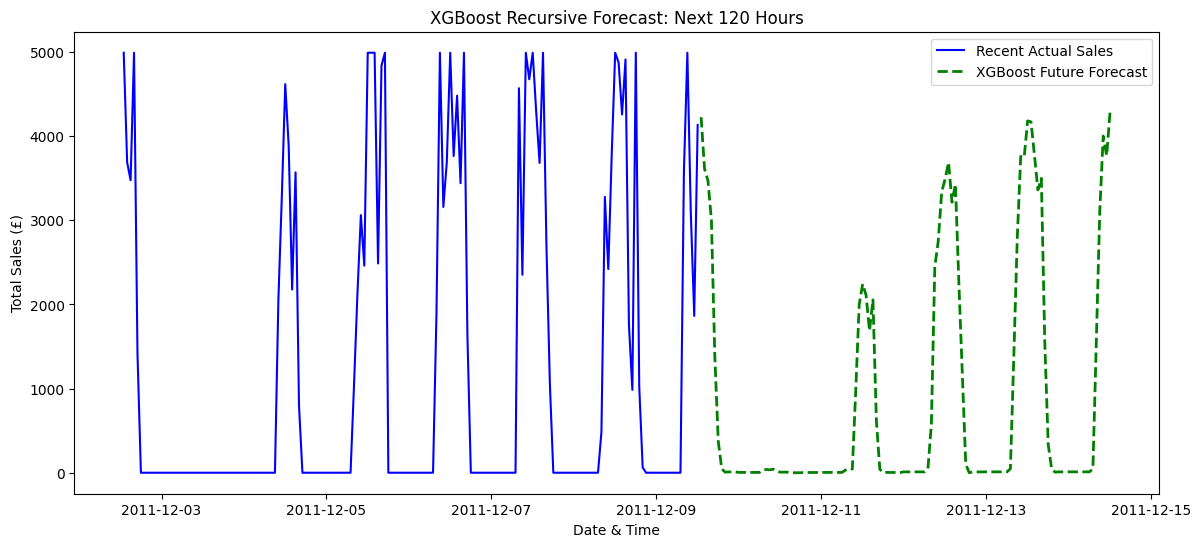

In [53]:
plt.figure(figsize=(14, 6))

plot_dates = pd.to_datetime(ml_df.index[-168:])
plt.plot(plot_dates, ml_df['y'][-168:], label='Recent Actual Sales', color='blue')

plt.plot(future_dates, future_predictions, label='XGBoost Future Forecast', color='green', linestyle='dashed', linewidth=2)

plt.title(f"XGBoost Recursive Forecast: Next {future_steps} Hours")
plt.xlabel("Date & Time")
plt.ylabel("Total Sales (£)")
plt.legend()
plt.show()